# Bài tập A8 — Phần 2: Transfer Learning với ResNet-18

So sánh **2 Chiến thuật chuyển giao tri thức (Transfer Learning)** trên tập dữ liệu Lỗi Thép NEU:
1. **Chiến thuật 1 (Feature Extraction)**: Đóng băng toàn bộ Backbone, chỉ huấn luyện lớp phân loại FC (`requires_grad = False`).
2. **Chiến thuật 2 (Fine-Tuning toàn diện)**: Mở khóa Backbone, huấn luyện với **Tốc độ học phân tầng (Differential Learning Rates)**: Backbone dùng LR siêu nhỏ (`1e-5`), FC dùng LR lớn hơn (`1e-4`).


## 1. Import Thư viện & Cấu hình Hệ thống


In [4]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import confusion_matrix, classification_report

CONFIG = {
    "data_dir": r"d:\ai_foundation\ComputerVision\phase_2\A8\dataset\NEU-DET\train\images",
    "img_size": (224, 224),
    "batch_size": 32,
    "epochs": 10,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
device = torch.device(CONFIG["device"])
print(f"PyTorch: {torch.__version__} | Device: {CONFIG['device']}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch: 2.5.1+cu121 | Device: cuda
GPU: NVIDIA GeForce RTX 2050 | VRAM: 4.3 GB


## 2. Chuẩn bị Dữ liệu & Data Augmentation (Pipeline chuẩn độc lập bộ nhớ)


In [5]:
# Bộ chuẩn hóa ImageNet
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# 1. Transform cơ bản cho Validation (chỉ Resize & Normalize)
val_tf = transforms.Compose([
    transforms.Resize(CONFIG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 2. Transform tăng cường cho Train (Lật ngang, lật dọc, chỉnh sắc nét)
# Lưu ý: Không dùng ColorJitter quá đà để tránh làm mờ các vết nứt vi mô
train_tf = transforms.Compose([
    transforms.Resize(CONFIG["img_size"]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 3. Tạo 2 Dataset độc lập (tránh lỗi chia sẻ con trỏ transform)
train_ds = ImageFolder(root=CONFIG["data_dir"], transform=train_tf)
val_ds   = ImageFolder(root=CONFIG["data_dir"], transform=val_tf)
class_names = train_ds.classes
num_classes = len(class_names)

# 4. Chia 80% Train, 20% Val với hạt giống seed 42 cố định
tr_n = int(0.8 * len(train_ds))
vl_n = len(train_ds) - tr_n
gen  = torch.Generator().manual_seed(42)
tr_idx, vl_idx = random_split(range(len(train_ds)), [tr_n, vl_n], generator=gen)

tr_set = Subset(train_ds, tr_idx)
vl_set = Subset(val_ds, vl_idx)

train_loader = DataLoader(tr_set, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=0)
val_loader   = DataLoader(vl_set, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

print(f"Tổng mẫu: {len(train_ds)} | Train: {tr_n} | Val: {vl_n}")
print(f"Số lớp: {num_classes} -> {class_names}")


Tổng mẫu: 1440 | Train: 1152 | Val: 288
Số lớp: 6 -> ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


## 3. Hàm Huấn luyện (Training Loop) & Đánh giá (Evaluation Loop)


In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

print("Hàm train_one_epoch và evaluate đã sẵn sàng!")


Hàm train_one_epoch và evaluate đã sẵn sàng!


---
## 4. CHIẾN THUẬT 1: Feature Extraction (Đóng băng toàn bộ Backbone)

### 📌 Ý tưởng kỹ thuật:
* **Khóa chặt toàn bộ Backbone** (`param.requires_grad = False`): Giữ nguyên các bộ lọc trích xuất đặc trưng của ImageNet.
* **Chỉ thay và huấn luyện tầng cuối `fc`** (`in_features=512 -> out_features=6`).
* **Ưu điểm**: Huấn luyện cực nhanh, tốn rất ít VRAM, không bao giờ lo overfit ở các tầng tích chập.
* **Learning Rate**: Dùng $\text{LR} = 10^{-3}$ cho lớp `fc` mới.


In [7]:
def build_resnet18_frozen(nc=6):
    # 1. Nạp ResNet18 kèm trọng số ImageNet V1
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    
    # 2. Đóng băng toàn bộ tham số trong mạng
    for param in m.parameters():
        param.requires_grad = False
        
    # 3. Thay thế tầng FC cuối cùng (mặc định requires_grad = True)
    in_features = m.fc.in_features  # 512
    m.fc = nn.Linear(in_features, nc)
    return m

model_s1 = build_resnet18_frozen(num_classes).to(device)

# Kiểm tra số lượng tham số cần học
total_params = sum(p.numel() for p in model_s1.parameters())
trainable_params = sum(p.numel() for p in model_s1.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"=== CHIẾN THUẬT 1: RESNET-18 (FROZEN BACKBONE) ===")
print(f"Tổng tham số         : {total_params:,}")
print(f"Tham số ĐÓNG BĂNG    : {frozen_params:,} ({frozen_params/total_params*100:.2f}%)")
print(f"Tham số CẦN HUẤN LUYỆN: {trainable_params:,} ({trainable_params/total_params*100:.2f}% - CHỈ TẦNG FC)")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\PC/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:06<00:00, 6.93MB/s]


=== CHIẾN THUẬT 1: RESNET-18 (FROZEN BACKBONE) ===
Tổng tham số         : 11,179,590
Tham số ĐÓNG BĂNG    : 11,176,512 (99.97%)
Tham số CẦN HUẤN LUYỆN: 3,078 (0.03% - CHỈ TẦNG FC)


In [8]:
# Huấn luyện Chiến thuật 1
criterion = nn.CrossEntropyLoss()
# CHỈ truyền model_s1.fc.parameters() vào Optimizer
optimizer_s1 = optim.Adam(model_s1.fc.parameters(), lr=1e-3)

hist_s1 = {"tl": [], "vl": [], "ta": [], "va": []}
epochs = CONFIG["epochs"]

print(f"Bắt đầu huấn luyện Chiến thuật 1 ({epochs} Epochs)...\n")
start_time = time.time()
for ep in range(1, epochs + 1):
    tl, ta = train_one_epoch(model_s1, train_loader, criterion, optimizer_s1, device)
    vl, va, _, _ = evaluate(model_s1, val_loader, criterion, device)
    hist_s1["tl"].append(tl); hist_s1["vl"].append(vl)
    hist_s1["ta"].append(ta); hist_s1["va"].append(va)
    print(f"[Epoch {ep:02d}/{epochs}] Train Loss: {tl:.4f} | Train Acc: {ta*100:.1f}%  ||  Val Loss: {vl:.4f} | Val Acc: {va*100:.1f}%")

time_s1 = time.time() - start_time
print(f"\nHoàn thành Chiến thuật 1 trong {time_s1:.1f}s | Best Val Acc: {max(hist_s1['va'])*100:.1f}%")


Bắt đầu huấn luyện Chiến thuật 1 (10 Epochs)...

[Epoch 01/10] Train Loss: 1.0731 | Train Acc: 70.4%  ||  Val Loss: 0.8734 | Val Acc: 71.2%
[Epoch 02/10] Train Loss: 0.3610 | Train Acc: 94.1%  ||  Val Loss: 0.2094 | Val Acc: 99.0%
[Epoch 03/10] Train Loss: 0.2185 | Train Acc: 96.7%  ||  Val Loss: 0.1369 | Val Acc: 98.6%
[Epoch 04/10] Train Loss: 0.1615 | Train Acc: 97.7%  ||  Val Loss: 0.1118 | Val Acc: 98.3%
[Epoch 05/10] Train Loss: 0.1339 | Train Acc: 98.1%  ||  Val Loss: 0.0871 | Val Acc: 99.3%
[Epoch 06/10] Train Loss: 0.1226 | Train Acc: 97.8%  ||  Val Loss: 0.0820 | Val Acc: 98.3%
[Epoch 07/10] Train Loss: 0.1152 | Train Acc: 97.7%  ||  Val Loss: 0.0684 | Val Acc: 99.3%
[Epoch 08/10] Train Loss: 0.0900 | Train Acc: 98.4%  ||  Val Loss: 0.0625 | Val Acc: 99.3%
[Epoch 09/10] Train Loss: 0.0860 | Train Acc: 98.1%  ||  Val Loss: 0.0579 | Val Acc: 99.3%
[Epoch 10/10] Train Loss: 0.0829 | Train Acc: 98.1%  ||  Val Loss: 0.0529 | Val Acc: 99.7%

Hoàn thành Chiến thuật 1 trong 63.0s | B

---
## 5. CHIẾN THUẬT 2: Fine-Tuning toàn diện với Tốc độ học phân tầng (Differential LR)

### 📌 Ý tưởng kỹ thuật:
* **Mở khóa toàn bộ mạng** (`param.requires_grad = True`): Cho phép các bộ lọc tích chập thích nghi sâu với bề mặt phôi thép kim loại.
* **Tốc độ học phân tầng (Differential / Layer-wise Learning Rate)**:
  * **Backbone (Conv layers)**: Đặt LR siêu nhỏ $\text{LR}_{\text{backbone}} = 10^{-5}$ (nhỏ gấp 10-100 lần) để uốn nắn nhẹ các bộ lọc viền/góc sẵn có, **không làm phá hỏng trọng số ImageNet**.
  * **Classifier (`fc`)**: Đặt LR lớn hơn $\text{LR}_{\text{fc}} = 10^{-4}$ để học gán nhãn 6 lớp lỗi nhanh chóng.
* Dùng **`AdamW`** kèm Weight Decay để kiểm soát chặt chẽ độ lớn của trọng số.


In [9]:
def build_resnet18_finetune(nc=6):
    # 1. Nạp ResNet18 kèm trọng số ImageNet V1
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    
    # 2. MỞ KHÓA TOÀN BỘ mạng (mặc định đã là True, đảm bảo rõ ràng)
    for param in m.parameters():
        param.requires_grad = True
        
    # 3. Thay lớp FC mới cho 6 lớp
    in_features = m.fc.in_features
    m.fc = nn.Linear(in_features, nc)
    return m

model_s2 = build_resnet18_finetune(num_classes).to(device)

# 4. Thiết lập Optimizer với 2 nhóm tham số (Differential Learning Rates)
backbone_params = [p for name, p in model_s2.named_parameters() if not name.startswith("fc")]
fc_params       = [p for name, p in model_s2.named_parameters() if name.startswith("fc")]

optimizer_s2 = optim.AdamW([
    {"params": backbone_params, "lr": 1e-5}, # LR siêu nhỏ cho Backbone
    {"params": fc_params,       "lr": 1e-4}, # LR vừa phải cho FC
], weight_decay=1e-2)

print(f"=== CHIẾN THUẬT 2: RESNET-18 (FULL FINE-TUNING VỚI DIFFERENTIAL LR) ===")
print(f"Số tham số Backbone (LR = 1e-5): {sum(p.numel() for p in backbone_params):,}")
print(f"Số tham số FC Layer (LR = 1e-4): {sum(p.numel() for p in fc_params):,}")


=== CHIẾN THUẬT 2: RESNET-18 (FULL FINE-TUNING VỚI DIFFERENTIAL LR) ===
Số tham số Backbone (LR = 1e-5): 11,176,512
Số tham số FC Layer (LR = 1e-4): 3,078


In [10]:
# Huấn luyện Chiến thuật 2
hist_s2 = {"tl": [], "vl": [], "ta": [], "va": []}

print(f"Bắt đầu huấn luyện Chiến thuật 2 ({epochs} Epochs)...\n")
start_time = time.time()
for ep in range(1, epochs + 1):
    tl, ta = train_one_epoch(model_s2, train_loader, criterion, optimizer_s2, device)
    vl, va, _, _ = evaluate(model_s2, val_loader, criterion, device)
    hist_s2["tl"].append(tl); hist_s2["vl"].append(vl)
    hist_s2["ta"].append(ta); hist_s2["va"].append(va)
    print(f"[Epoch {ep:02d}/{epochs}] Train Loss: {tl:.4f} | Train Acc: {ta*100:.1f}%  ||  Val Loss: {vl:.4f} | Val Acc: {va*100:.1f}%")

time_s2 = time.time() - start_time
print(f"\nHoàn thành Chiến thuật 2 trong {time_s2:.1f}s | Best Val Acc: {max(hist_s2['va'])*100:.1f}%")


Bắt đầu huấn luyện Chiến thuật 2 (10 Epochs)...

[Epoch 01/10] Train Loss: 1.2184 | Train Acc: 62.6%  ||  Val Loss: 0.8430 | Val Acc: 87.8%
[Epoch 02/10] Train Loss: 0.4057 | Train Acc: 95.9%  ||  Val Loss: 0.2232 | Val Acc: 99.0%
[Epoch 03/10] Train Loss: 0.1884 | Train Acc: 99.0%  ||  Val Loss: 0.1036 | Val Acc: 99.3%
[Epoch 04/10] Train Loss: 0.1175 | Train Acc: 98.5%  ||  Val Loss: 0.0632 | Val Acc: 99.7%
[Epoch 05/10] Train Loss: 0.0753 | Train Acc: 99.6%  ||  Val Loss: 0.0419 | Val Acc: 99.7%
[Epoch 06/10] Train Loss: 0.0607 | Train Acc: 99.6%  ||  Val Loss: 0.0300 | Val Acc: 99.7%
[Epoch 07/10] Train Loss: 0.0430 | Train Acc: 99.5%  ||  Val Loss: 0.0240 | Val Acc: 99.7%
[Epoch 08/10] Train Loss: 0.0410 | Train Acc: 99.6%  ||  Val Loss: 0.0191 | Val Acc: 99.7%
[Epoch 09/10] Train Loss: 0.0362 | Train Acc: 99.5%  ||  Val Loss: 0.0143 | Val Acc: 99.7%
[Epoch 10/10] Train Loss: 0.0258 | Train Acc: 99.8%  ||  Val Loss: 0.0131 | Val Acc: 99.7%

Hoàn thành Chiến thuật 2 trong 102.9s | 

---
## 6. So sánh Đối đầu (Head-to-Head Comparison) giữa 2 Chiến thuật


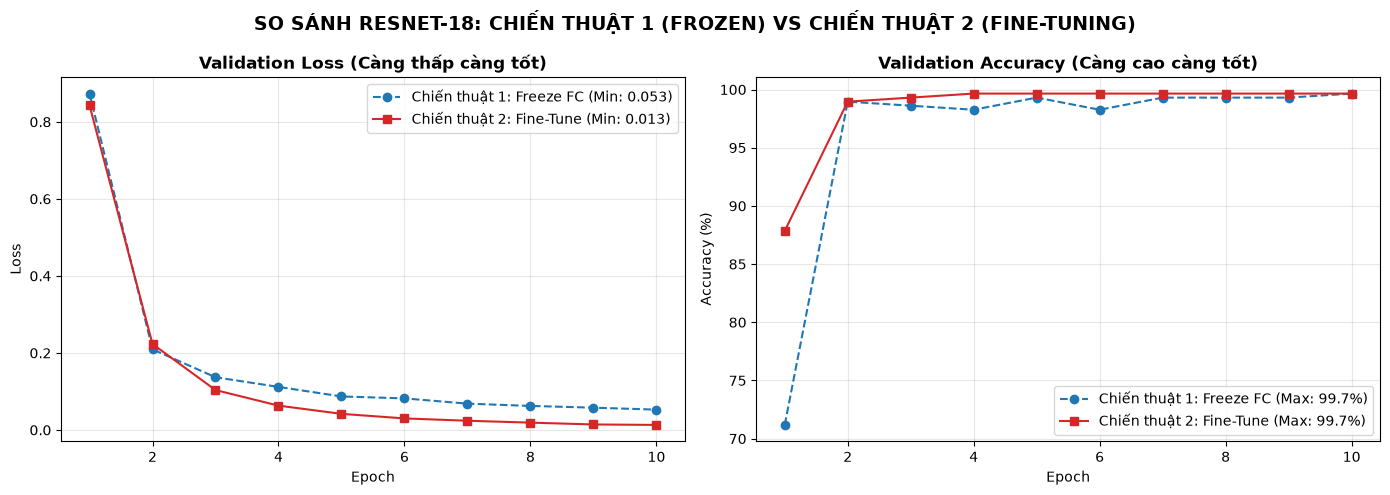

In [11]:
ep_range = range(1, epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Đồ thị Loss
ax1.plot(ep_range, hist_s1["vl"], "o--", color="tab:blue", label=f"Chiến thuật 1: Freeze FC (Min: {min(hist_s1['vl']):.3f})")
ax1.plot(ep_range, hist_s2["vl"], "s-",  color="tab:red",  label=f"Chiến thuật 2: Fine-Tune (Min: {min(hist_s2['vl']):.3f})")
ax1.set_title("Validation Loss (Càng thấp càng tốt)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)

# 2. Đồ thị Accuracy
ax1_acc = [a * 100 for a in hist_s1["va"]]
ax2_acc = [a * 100 for a in hist_s2["va"]]
ax2.plot(ep_range, ax1_acc, "o--", color="tab:blue", label=f"Chiến thuật 1: Freeze FC (Max: {max(ax1_acc):.1f}%)")
ax2.plot(ep_range, ax2_acc, "s-",  color="tab:red",  label=f"Chiến thuật 2: Fine-Tune (Max: {max(ax2_acc):.1f}%)")
ax2.set_title("Validation Accuracy (Càng cao càng tốt)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("SO SÁNH RESNET-18: CHIẾN THUẬT 1 (FROZEN) VS CHIẾN THUẬT 2 (FINE-TUNING)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 7. Đánh giá Chuyên sâu mô hình Chiến thuật 2 (Confusion Matrix & Classification Report)

Đặc biệt kiểm tra chỉ số **Recall** của các lớp dễ bị bỏ sót như `scratches` (vết xước) và `crazing` (vết nứt).


=== BÁO CÁO PHÂN LOẠI CHI TIẾT (Chiến thuật 2 (Fine-Tuning)) ===
                 precision    recall  f1-score   support

        crazing     1.0000    1.0000    1.0000        55
      inclusion     0.9787    1.0000    0.9892        46
        patches     1.0000    1.0000    1.0000        42
 pitted_surface     1.0000    1.0000    1.0000        55
rolled-in_scale     1.0000    1.0000    1.0000        47
      scratches     1.0000    0.9767    0.9882        43

       accuracy                         0.9965       288
      macro avg     0.9965    0.9961    0.9962       288
   weighted avg     0.9966    0.9965    0.9965       288



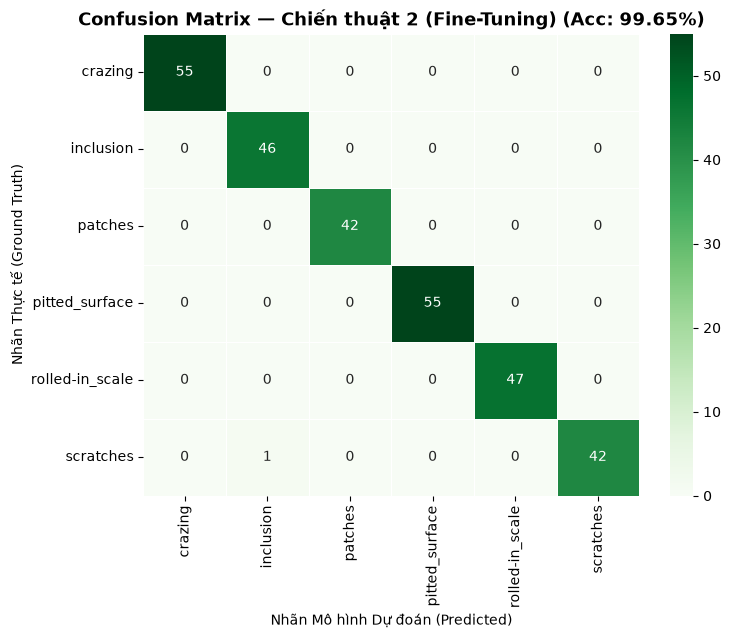

In [12]:
# Chọn model tốt hơn (thường là model_s2)
best_model = model_s2 if max(hist_s2["va"]) >= max(hist_s1["va"]) else model_s1
model_name = "Chiến thuật 2 (Fine-Tuning)" if best_model is model_s2 else "Chiến thuật 1 (Frozen)"

val_loss, val_acc, preds, labels_true = evaluate(best_model, val_loader, criterion, device)

print(f"=== BÁO CÁO PHÂN LOẠI CHI TIẾT ({model_name}) ===")
print(classification_report(labels_true, preds, target_names=class_names, digits=4))

# Vẽ Confusion Matrix
cm = confusion_matrix(labels_true, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.title(f"Confusion Matrix — {model_name} (Acc: {val_acc*100:.2f}%)", fontsize=13, fontweight="bold")
plt.xlabel("Nhãn Mô hình Dự đoán (Predicted)")
plt.ylabel("Nhãn Thực tế (Ground Truth)")
plt.show()


---
## 8. Phân tích Các trường hợp phân loại sai (Error Analysis)


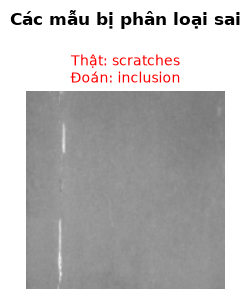

In [13]:
wrong_imgs, wrong_true, wrong_pred = [], [], []
best_model.eval()
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outs = best_model(imgs)
        ps = outs.argmax(dim=1)
        mask = ps != lbls
        if mask.any():
            for img, t, p in zip(imgs[mask], lbls[mask], ps[mask]):
                wrong_imgs.append(img.cpu())
                wrong_true.append(class_names[t.item()])
                wrong_pred.append(class_names[p.item()])
                if len(wrong_imgs) >= 6: break
        if len(wrong_imgs) >= 6: break

if wrong_imgs:
    fig, axes = plt.subplots(1, len(wrong_imgs), figsize=(15, 3))
    if len(wrong_imgs) == 1: axes = [axes]
    for ax, img, t, p in zip(axes, wrong_imgs, wrong_true, wrong_pred):
        # De-normalize để hiển thị ảnh RGB bình thường
        img_disp = img.clone().permute(1, 2, 0).numpy()
        img_disp = np.array(std) * img_disp + np.array(mean)
        img_disp = np.clip(img_disp, 0, 1)
        ax.imshow(img_disp)
        ax.set_title(f"Thật: {t}\nĐoán: {p}", color="red", fontsize=10)
        ax.axis("off")
    plt.suptitle("Các mẫu bị phân loại sai", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Tuyệt vời! Không có ảnh nào bị phân loại sai trên tập kiểm định!")


In [ ]:
import time
dummy = torch.randn(1, 3, 224, 224).to(device)

# Đo thời gian suy luận 1 ảnh
start = time.time()
for _ in range(100):
    _ = model_s2(dummy)
latency = (time.time() - start) / 100 * 1000
print(f"Độ trễ trung bình: {latency:.2f} ms")


Độ trễ trung bình: 5.00 ms


: 